<a href="https://colab.research.google.com/github/lete543/Business-Inteligence-and-Analytics/blob/main/Let%C3%ADcia_castro_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/michalis0/Business-Intelligence-and-Analytics/blob/master/Assignment/assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as py
import plotly.graph_objs as go
import statistics


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, recall_score, precision_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

warnings.filterwarnings('ignore')
%matplotlib inline

<div>
<td>
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/2/2b/Logo_Universit%C3%A9_de_Lausanne.svg/2000px-Logo_Universit%C3%A9_de_Lausanne.svg.png" style="padding-right:10px;width:240px;float:left"/></td>
<h2 style="white-space: nowrap">Business Intelligence and Analytics Personal Assignment</h2></td>
<hr style="clear:both">
<p style="font-size:0.85em; margin:2px; text-align:justify">

</div>

# IMPORTANT

Question 1: Before starting this assignment, please indicate whether this course is worth 4.5 or 6 credits to you. Please answer truthfully, as checks will be made afterwards. This question is only intended to facilitate the calculation of final points.

> TODO: (6 CRÉDITS)

# Part 1: Climate Analytics - Rice vs Wheat in a Changing World

## Context

You work as a junior data analyst at SerriFleur, an international NGO focused on sustainable agriculture in the face of climate change. Your team is investigating how climate conditions and farming practices affect the yields of rice and wheat — two of the most critical staple crops globally.

You’ve just received a massive dataset from the research division: "Hydroponix.csv". Your task is to extract insights, build models, and tell a compelling story from the data. You can find the dataset here: https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/refs/heads/master/data/Hydroponix.csv

Columns Overview:

* `Year` : Year of the observation.

* `Country` : Country where the data was collected.

* `Region` : Specific region within the country.

* `Crop_Type` : Type of agricultural crop observed.

* `Average_Temperature` : Annual average temperature in degrees Celsius.

* `Total_Precipitation` : Total annual precipitation in millimeters.

* `CO2_Emissions` : CO₂ emissions in million tons.

* `Crop_Yield` : Agricultural yield in tons per hectare.

* `Extreme_Weather_Events` : Number of recorded extreme weather events.

* `Irrigation_Access` : Percentage of cultivated land with access to irrigation.

* `Pesticide_Use` : Pesticide use in kilograms per hectare.

* `Fertilizer_Use` : Fertilizer use in kilograms per hectare.

* `Soil_Health_Index` : Soil quality index (out of 100).

* `Economic_Impact` : Economic impact in million USD.

In [ ]:
# TODO: Your code here
data_climate = pd.read_csv("https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/refs/heads/master/data/Hydroponix.csv")
print(data_climate.head())
data_climate.info()

   Year Country         Region  Crop_Type  Average_Temperature  \
0  2001   India    West Bengal       Corn                 1.55   
1  2024   China          North       Corn                 3.23   
2  2001  France  Ile-de-France      Wheat                21.11   
3  2001  Canada       Prairies     Coffee                27.85   
4  1998   India     Tamil Nadu  Sugarcane                 2.19   

   Total_Precipitation  CO2_Emissions  Crop_Yield  Irrigation_Access  \
0               447.06          15.22       1.737              14.54   
1              2913.57          29.82       1.737              11.05   
2              1301.74          25.75       1.719              84.42   
3              1154.36          13.91       3.890              94.06   
4              1627.48          11.81       1.080              95.75   

   Pesticide_Use  Fertilizer_Use  Soil_Health_Index  Economic_Impact  
0          10.08           14.78              83.25           808.13  
1          33.06           2

## Exercise 1: Data Cleaning & Preprocessing



The dataset you’ve received contains data from multiple countries, various crops, and inconsistent formatting. Your first job is to narrow the scope of your study and prepare a clean dataset that’s ready for analysis.

Your mission:

*   Filter the dataset to focus only on rice and wheat
*   Drop the regional identifiers column
*   Group the data by Country, Year and Crop_type but don't put them as index (*Hint: specific parameter of `groupby`*) and calculate the mean of each column
*   Change the type of the columns `Country` and `Crop_type`


In [ ]:
# Data cleaning
# TODO: Your code here

# Filtra apenas Rice e Wheat
rice_wheat_data = data_climate[data_climate['Crop_Type'].isin(['Rice', 'Wheat'])].copy()
rice_wheat_data.drop(columns=['Region'], inplace=True)

# Converte colunas numéricas para float (forçando coerção e garantindo consistência)
for col in rice_wheat_data.columns:
    if col not in ['Country', 'Year', 'Crop_Type']:
        rice_wheat_data[col] = pd.to_numeric(rice_wheat_data[col], errors='coerce')

# Agrupamento após limpeza (ordem igual à versão correta)
final_data = rice_wheat_data.groupby(['Country', 'Year', 'Crop_Type'], as_index=False).mean()

# Preenchendo os NaNs que podem surgir após o agrupamento com 0
final_data = final_data.fillna(0)

final_data_original = final_data.copy()

# Checagem de tipos e visualização
print(final_data.dtypes)
print(final_data.info())
print(final_data.head())


Country                 object
Year                     int64
Crop_Type               object
Average_Temperature    float64
Total_Precipitation    float64
CO2_Emissions          float64
Crop_Yield             float64
Irrigation_Access      float64
Pesticide_Use          float64
Fertilizer_Use         float64
Soil_Health_Index      float64
Economic_Impact        float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 665 entries, 0 to 664
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Country              665 non-null    object 
 1   Year                 665 non-null    int64  
 2   Crop_Type            665 non-null    object 
 3   Average_Temperature  665 non-null    float64
 4   Total_Precipitation  665 non-null    float64
 5   CO2_Emissions        665 non-null    float64
 6   Crop_Yield           665 non-null    float64
 7   Irrigation_Access    665 non-null    float64
 8   Pest

In [ ]:
# Question 2: Find the list of crop types produced by SerriFleur # TODO: Your code here
list(data_climate['Crop_Type'].unique())
#sorted(data_climate['Crop_Type'].unique())

['Corn',
 'Wheat',
 'Coffee',
 'Sugarcane',
 'Fruits',
 'Rice',
 'Barley',
 'Vegetables',
 'Soybeans',
 'Cotton']

In [ ]:
# Question 3: Find the total number of countries where Serrifleur operates in # TODO: Your code here
lista_countries = final_data['Country'].unique()

print(lista_countries)
len(lista_countries)


['Argentina' 'Australia' 'Brazil' 'Canada' 'China' 'France' 'India'
 'Nigeria' 'Russia' 'USA']


10

**Note on Climate Variables per Crop**:

> You may notice that climate-related variables such as average temperature and total precipitation vary across different crops, even for the same country and year. This is because each crop is typically grown in different regions within a country, depending on factors like soil conditions, irrigation availability, and climatic suitability. For example, wheat might be cultivated in cooler northern regions while corn is grown in warmer southern areas. Therefore, the recorded climate data reflects regional conditions specific to where each crop is grown, rather than national averages. This is an important consideration when interpreting the results of this analysis.

## Exercise 2: Exploratory Data Analysis

Before diving into modeling, your supervisor wants a clear picture of the current state of affairs in South America. You’re tasked with visualizing total precipitation level, economic impacts and soil health.

Your mission:


*   Plot total precipitation evolution over the years for each crop in Argentina
*   Create a pie chart that shows the percentage share of the total economic impact for each crop in Brazil
*   Create boxplots comparing soil health across crops and all the countries


In [ ]:
# Question 4: Create the graph of the total precipitation evolution over the years for each crop in Argentina # TODO: Your code here
Argentina_precipitation = final_data[final_data.Country == 'Argentina']
Argentina_precipitation = Argentina_precipitation.drop(columns=['Country'])

Argentina_precipitation.head(100)

,Year,Crop_Type,Average_Temperature,Total_Precipitation,CO2_Emissions,Crop_Yield,Irrigation_Access,Pesticide_Use,Fertilizer_Use,Soil_Health_Index,Economic_Impact
0,1990,Rice,25.250000,1540.486667,14.126667,2.686333,58.413333,42.223333,18.710000,72.513333,618.393333
1,1990,Wheat,10.755000,867.305000,18.350000,2.686500,39.830000,16.875000,75.195000,75.215000,650.170000
2,1991,Rice,14.317500,761.692500,15.115000,2.538000,42.930000,29.302500,59.152500,59.955000,749.937500
3,1992,Rice,14.865000,1190.220000,19.710000,2.794500,57.740000,33.495000,54.680000,40.260000,1190.750000
4,1992,Wheat,27.520000,1304.713333,20.786667,1.838667,78.210000,30.903333,25.186667,53.616667,581.710000
...,...,...,...,...,...,...,...,...,...,...,...
59,2022,Wheat,13.560000,1469.693333,17.423333,1.030333,59.990000,25.386667,58.923333,58.330000,338.840000
60,2023,Rice,11.861667,1526.093333,19.041667,2.202333,55.056667,30.353333,55.161667,47.901667,781.190000
61,2023,Wheat,16.726667,1557.026667,14.733333,2.156000,49.023333,25.393333,49.486667,47.690000,689.503333
62,2024,Rice,16.113333,1584.540000,24.446667,1.866000,67.800000,8.236667,71.503333,40.116667,663.706667


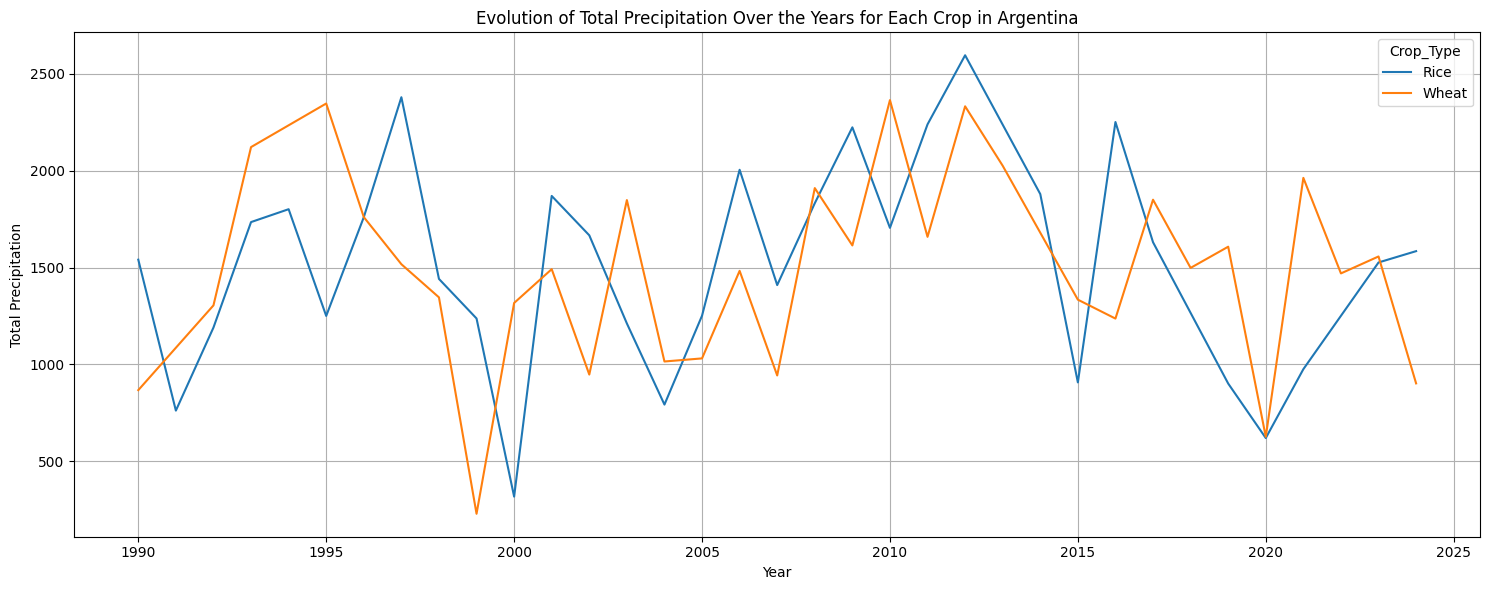

In [ ]:
plot_1 = plt.figure(figsize=(15, 6))
#unique - without repetions
for crop in (Argentina_precipitation['Crop_Type'].unique()):

    data_crop = Argentina_precipitation[Argentina_precipitation['Crop_Type'] == crop]
    plt.plot(data_crop['Year'], data_crop['Total_Precipitation'], label=crop)

# Títulos e legendas
plt.title("Evolution of Total Precipitation Over the Years for Each Crop in Argentina")
plt.xlabel("Year")
plt.ylabel("Total Precipitation")
plt.legend(title="Crop_Type")
plt.grid(True)
plt.tight_layout()
plt.show()


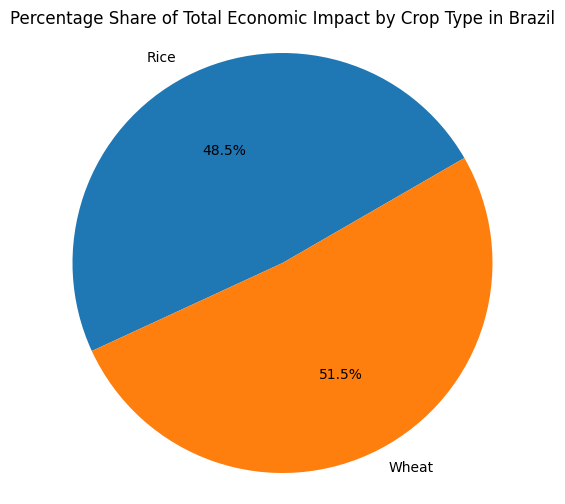

In [ ]:
# Question 5: Create the pie chart that shows the percentage share of the totale economic impact for each crop in Brazil # TODO: Your code here
##Question 5: Create the (pie chart) that shows the (percentage) share of the (totale economic impact) for (each crop) in (Brazil)

Brazil_economic = final_data[final_data['Country'] == 'Brazil']
Brazil_economic = Brazil_economic[['Crop_Type','Economic_Impact']]
Brazil_economic = Brazil_economic.groupby(['Crop_Type'], as_index=False).sum()

plt.figure(figsize=(7, 6))
plt.pie(Brazil_economic['Economic_Impact'], labels=Brazil_economic['Crop_Type'], autopct='%1.1f%%', startangle=30)
plt.title('Percentage Share of Total Economic Impact by Crop Type in Brazil')
plt.axis('equal')  # circle
plt.show()

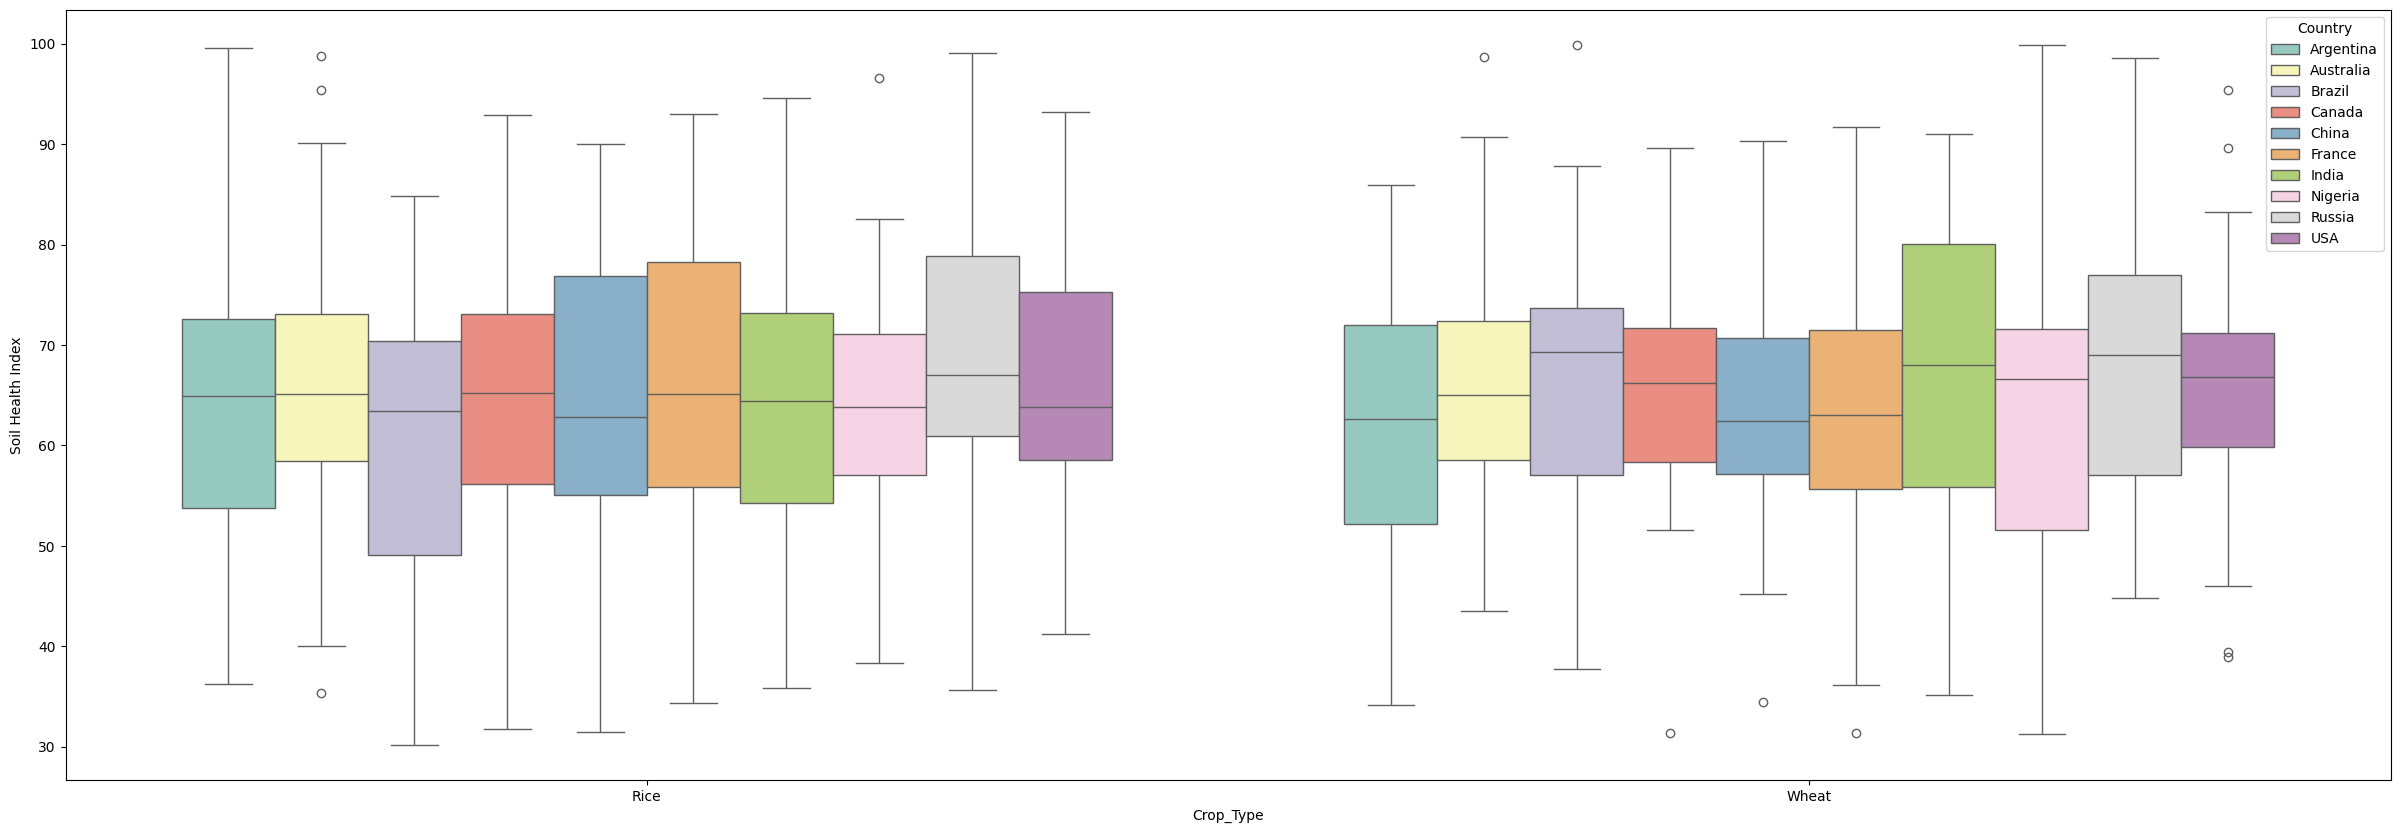

In [ ]:
# Question 6: Create the boxplots that compare the soil health index across crops and all the countries # TODO: Your code here
Soil_crop_country = final_data[ ['Crop_Type','Country','Soil_Health_Index'] ]
fig, ax = plt.subplots(figsize=(30, 10))
graph_box = sns.boxplot(y='Soil_Health_Index', hue='Country', x='Crop_Type', data=Soil_crop_country, ax=ax, palette='Set3')
graph_box.set_ylabel('Soil Health Index')
graph_box.set_xlabel('Crop_Type')
plt.show()

## Exercise 3: Clustering

SerriFleur aims to classify countries based on their farming practices in order to provide region-specific recommendations. You propose using unsupervised learning to identify distinct fertilizer usage profiles.

Your mission:



*   For each crop type, use agglomerative clustering on fertilizer usage with 4 clusters, euclidian distance metric and ward linkage
*   Analyze whether wheat and rice follow similar cluster pattern
*   Plot the dendrogram representation of fertilizer usage, for each crop type, with euclidian distance metric and average linkage


In [ ]:
# Agglomerative Clustering for Rice
# Question 7: Find the number of values in each clustering label
# TODO: Your code here

# Select the Rice data /  use (agglomerative clustering) on (fertilizer usage) with (4 clusters), (euclidian distance metric) and (ward linkage)
fertilizer_data_rice = final_data[final_data['Crop_Type'] == 'Rice']
fertilizer_data_rice = fertilizer_data_rice[['Fertilizer_Use']]

clustering_data_rice = AgglomerativeClustering(n_clusters=4, metric="euclidean", linkage="ward")
clustering_data_rice.fit(fertilizer_data_rice)

rice_clusters = clustering_data_rice.labels_
print("rice Clusters:\n", rice_clusters)

g1,g2,g3,g4 = 0,0,0,0
for i in range(len(rice_clusters)):
  if(rice_clusters[i] == 0):
    g1 += 1
  elif(rice_clusters[i] == 1):
    g2 += 1
  elif(rice_clusters[i] == 2):
    g3 += 1
  else:
    g4 += 1

print(g1,g2,g3,g4)



rice Clusters:
 [1 0 0 2 3 2 3 1 2 0 0 0 0 0 0 2 1 0 3 1 0 3 3 0 3 3 3 0 0 1 0 2 2 1 2 2 3
 0 2 0 0 1 0 3 3 0 3 1 2 1 2 3 0 0 3 0 0 2 0 1 3 1 0 2 0 2 0 3 1 0 0 3 1 0
 3 0 3 0 0 1 1 0 0 2 3 1 0 3 0 2 3 0 0 2 2 0 0 1 0 0 3 3 1 1 2 0 3 0 0 1 0
 0 1 3 0 0 3 3 0 0 1 3 0 3 0 2 3 1 3 0 3 3 0 0 2 3 0 0 2 3 3 0 3 3 0 1 0 1
 0 3 0 1 0 1 0 0 3 1 3 0 3 0 0 0 2 0 3 1 2 3 0 0 0 2 2 2 2 3 2 0 0 2 0 2 3
 3 0 1 0 1 2 2 0 0 2 3 3 0 0 2 0 0 2 1 3 2 3 0 1 3 3 2 3 0 0 1 0 0 0 2 3 2
 2 3 0 1 0 1 1 0 1 2 3 0 3 3 0 1 3 3 3 0 1 0 0 2 0 0 0 0 0 2 3 2 3 3 3 3 2
 0 3 3 2 0 3 1 0 0 3 3 2 0 0 1 0 1 1 0 3 2 2 3 0 1 0 0 3 0 1 3 2 0 2 0 0 2
 0 3 0 2 2 0 0 0 2 0 0 0 1 3 3 1 2 3 0 3 0 2 0 0 0 3 2 1 3 2 0 0 3 0 1 0]
137 50 60 85


In [ ]:
# Agglomerative Clustering for Wheat
# Question 7: Find the number of values in each clustering label
# TODO: Your code here

fertilizer_data_wheat = final_data[final_data['Crop_Type'] == 'Wheat']
fertilizer_data_wheat = fertilizer_data_wheat[['Fertilizer_Use']]

clustering_data_wheat = AgglomerativeClustering(n_clusters=4, metric="euclidean", linkage="ward")
clustering_data_wheat.fit(fertilizer_data_wheat)

wheat_clusters = clustering_data_wheat.labels_
print("wheat Clusters:\n", wheat_clusters)

g1,g2,g3,g4 = 0,0,0,0
for i in range(len(wheat_clusters)):
  if(wheat_clusters[i] == 0):
    g1 += 1
  elif(wheat_clusters[i] == 1):
    g2 += 1
  elif(wheat_clusters[i] == 2):
    g3 += 1
  else:
    g4 += 1

print(g1,g2,g3,g4)



wheat Clusters:
 [2 3 1 0 1 1 1 3 2 1 1 0 0 0 0 0 3 1 3 3 1 1 2 0 0 0 1 0 0 0 1 0 0 0 1 0 1
 1 2 1 1 0 0 1 2 3 0 1 1 0 3 1 0 3 2 1 2 0 0 3 0 0 0 1 1 1 0 1 1 0 3 1 0 1
 1 0 1 0 0 1 0 1 1 0 1 3 1 1 1 1 2 1 0 0 1 3 1 0 2 3 0 1 0 0 1 1 0 1 1 1 0
 1 1 2 0 3 0 3 1 1 1 1 1 1 2 1 1 0 2 0 3 0 3 0 3 1 1 3 1 3 1 1 1 3 3 0 0 2
 1 0 1 0 0 1 1 0 0 1 0 3 1 1 2 2 0 2 2 0 0 0 2 0 0 0 2 1 1 0 0 0 3 1 0 0 1
 2 0 1 2 0 3 1 3 0 0 1 0 1 1 0 0 0 3 0 0 1 0 2 1 1 0 0 3 1 1 1 0 0 3 1 0 1
 1 3 0 1 0 1 2 1 1 1 0 2 1 2 0 1 2 1 0 2 1 1 3 1 0 0 1 0 0 1 1 1 1 0 0 0 3
 1 0 0 0 1 3 3 1 1 0 1 0 1 0 0 0 2 1 0 0 1 2 0 0 0 1 2 0 0 3 1 1 2 1 1 0 2
 0 0 3 0 0 1 0 0 3 1 3 3 0 0 1 0 1 0 2 0 1 3 3 3 3 1 0 1 2 0 0 0 1 3 0 0 1]
129 126 34 44


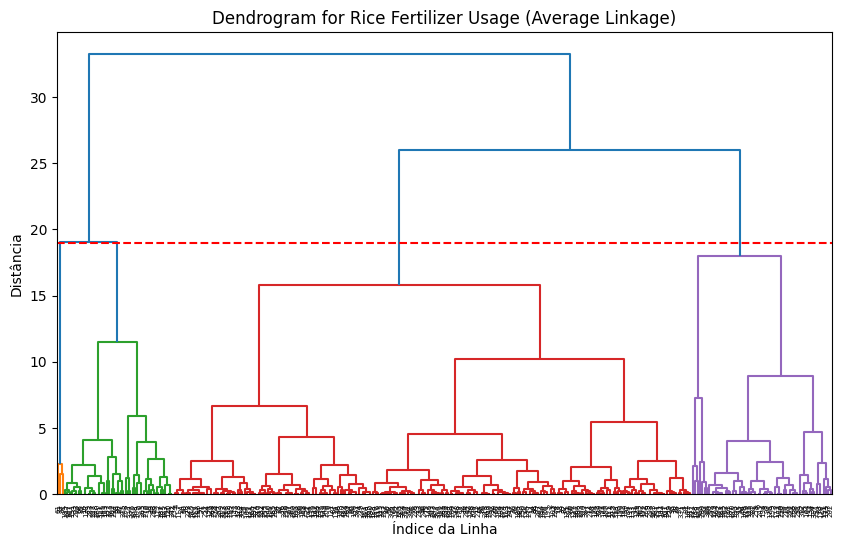

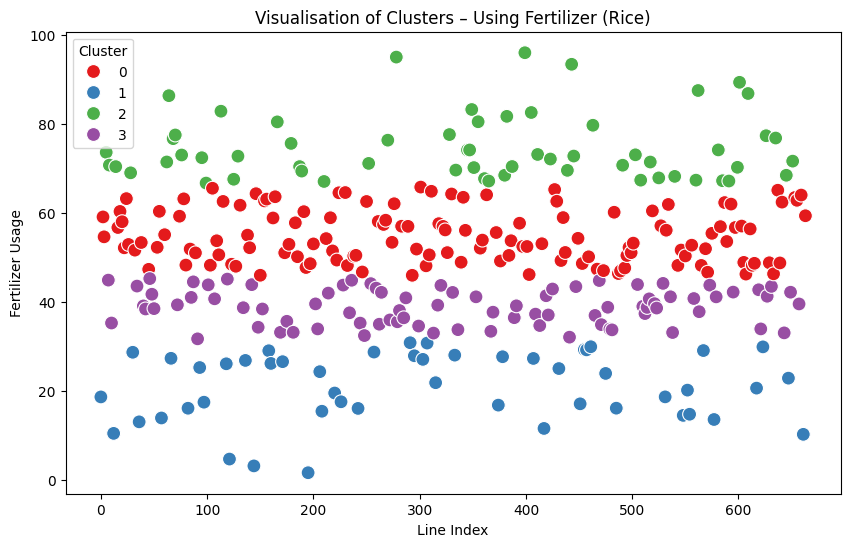

In [ ]:
# Question 8: Hierarchical Clustering for Rice
# Don't forget to reshape the values with numpy

column_rice_cluster = rice_clusters.reshape(-1, 1)
# Atribuindo os clusters ao DataFrame
fertilizer_data_rice['Cluster'] = column_rice_cluster

# Linkage para clustering hierárquico
linked_rice = linkage(fertilizer_data_rice[['Fertilizer_Use']], method='average', metric='euclidean')


# Plot do dendrograma
plt.figure(figsize=(10, 6))
dendrogram(linked_rice,color_threshold=19)
#dendrogram(linked_w, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrogram for Rice Fertilizer Usage (Average Linkage)')
plt.xlabel('Índice da Linha')
plt.ylabel('Distância')
plt.axhline(y=19, color='r', linestyle='--')
plt.show()

# Plot do scatterplot com os clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=fertilizer_data_rice.index,
    y='Fertilizer_Use',
    hue='Cluster',
    palette='Set1',
    data=fertilizer_data_rice,
    s=100
)

plt.title('Visualisation of Clusters – Using Fertilizer (Rice)')
plt.xlabel('Line Index')  # Índice da linha no DataFrame
plt.ylabel('Fertilizer Usage')
plt.legend(title='Cluster')
plt.show()

#Quanto maior o valor no eixo y, mais distantes (menos similares) são os clusters que estão sendo unidos naquele ponto.

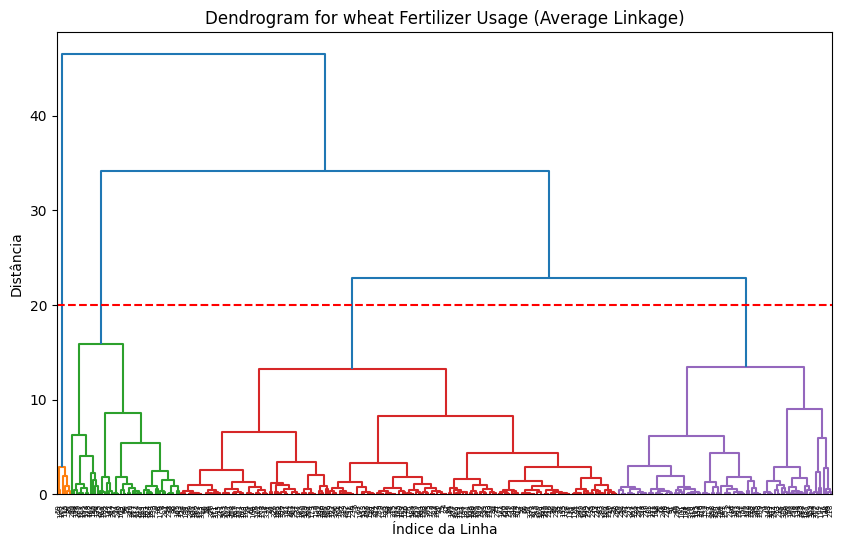

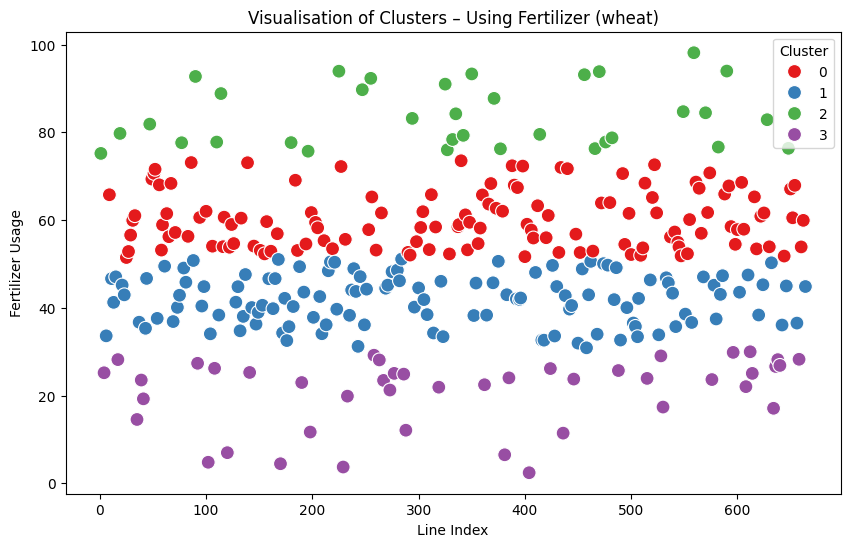

In [ ]:
#Question 8: Hierarchical Clustering for Wheat
# TODO: Your code here

#Don't forget to reshape the values with numpy

column_wheat_cluster = wheat_clusters.reshape(-1, 1)
#Atribuindo os clusters ao DataFrame
fertilizer_data_wheat['Cluster'] = column_wheat_cluster

#Linkage para clustering hierárquico
linked_wheat = linkage(fertilizer_data_wheat[['Fertilizer_Use']], method='average', metric='euclidean')

plt.figure(figsize=(10, 6))
dendrogram(linked_wheat,color_threshold=20)
#dendrogram(linked_w, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrogram for wheat Fertilizer Usage (Average Linkage)')
plt.xlabel('Índice da Linha')
plt.ylabel('Distância')
plt.axhline(y=20, color='r', linestyle='--')
plt.show()

#Plot do scatterplot com os clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=fertilizer_data_wheat.index,
    y='Fertilizer_Use',
    hue='Cluster',
    palette='Set1',
    data=fertilizer_data_wheat,
    s=100
)

plt.title('Visualisation of Clusters – Using Fertilizer (wheat)')
plt.xlabel('Line Index')  # Índice da linha no DataFrame
plt.ylabel('Fertilizer Usage')
plt.legend(title='Cluster')
plt.show()

#Quanto maior o valor no eixo y, mais distantes (menos similares) são os clusters que estão sendo unidos naquele ponto.

## Exercise 4: Simple Linear Regression

A policymaker asks a simple question: "Does CO₂ have a measurable impact on crop yield for wheat and rice ?"
You decide to test this using a basic regression model.

Your mission:

*   Plot the heatmap of correlations for numeric columns only.
*   Model Crop_Yield as a function of CO2_Emissions (with `test_size = 0.3`, `random_state = 123` and `shuffle=True`).
*   Use MinMaxScaler and find the $R^2$, the MSE and the MAE.






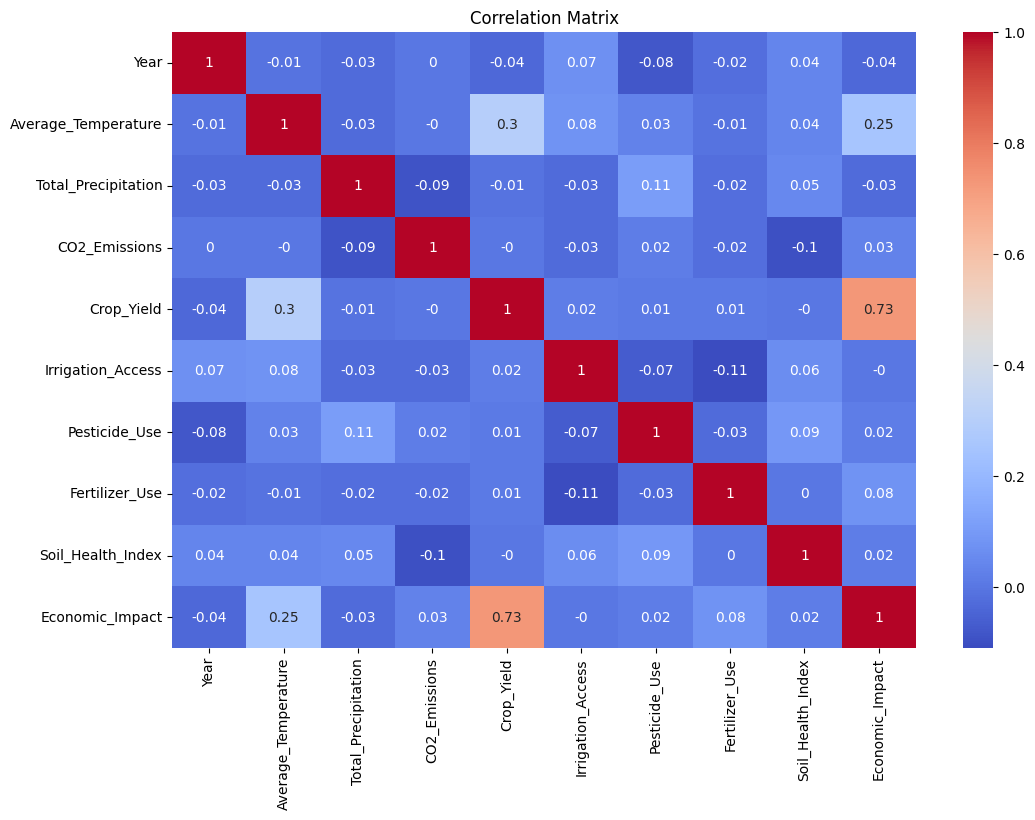

In [ ]:
# Question 9: Plot heatmap of correlations
# TODO: Your code here

#Heatmaps enable you to visualize very easily the pearsons coefficient of correlation
#print(final_data.head())
#print(final_data.corr(numeric_only=True).round(2))
plt.figure(figsize=(12, 8))
sns.heatmap(final_data.corr(numeric_only=True).round(2), annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()
#final_data.info()


#+1	Correlação positiva perfeita – quando uma variável aumenta, a outra aumenta exatamente na mesma proporção.
#0	Sem correlação linear – as variáveis não têm relação direta (pode haver relação não-linear).
#-1	Correlação negativa perfeita – quando uma variável aumenta, a outra diminui exatamente na mesma proporção.

#"Does (CO₂) have a measurable impact on (crop yield) for (wheat and rice )?"
# You decide to test this using a basic regression model. (which degree will be your function)
#resuktados distintos , será que é normalizado?

In [ ]:
# Seperate features and labels
#feature = x, label = y
# TODO: Your code here
X_1 = final_data[['CO2_Emissions']]
y_1 = final_data[['Crop_Yield']]


In [ ]:
# Split data into train and test sets # TODO: Your code here
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.3, random_state=123, shuffle=True)


In [ ]:
# Scale the data/Normalization # TODO: Your code here

scaler = MinMaxScaler()
# Fit the scaler
scaler.fit(X_train_1)
# Transform the train and the test set
X_test_1 = scaler.transform(X_test_1)
X_train_1 = scaler.fit_transform(X_train_1)



In [ ]:
# Create (linear regression model) and fit into the training data

# TODO: Your code here

# There are three steps to model something with sklearn
# 1. Set up the model
# Create (linear regression model) and fit into the training data


model = LinearRegression(fit_intercept= True)
model.fit(X_train_1, y_train_1)
a = model.coef_[0].item()
b = model.intercept_[0].item()

print(f"Equação da reta: y = {a:.2f} * x + {b:.2f}")


Equação da reta: y = 0.10 * x + 2.21


R²: -0.01
MSE: 0.48
MAE: 0.55


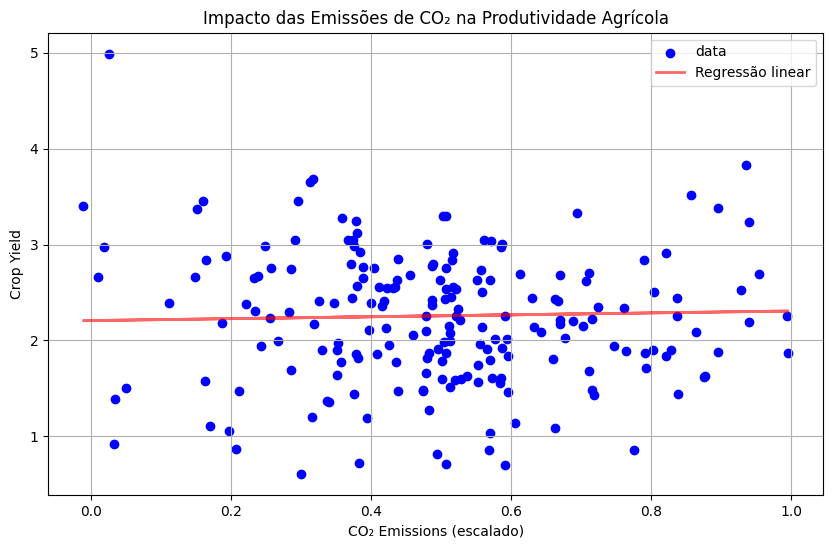

In [ ]:
# Question 10: Print out the R2, MSE and MAE score

y_pred_1 = model.predict(X_test_1)

r2 = r2_score(y_test_1, y_pred_1)
mse = mean_squared_error(y_test_1, y_pred_1)
mae = mean_absolute_error(y_test_1, y_pred_1)

print(f"R²: {r2:.2f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")


plt.figure(figsize=(10, 6))
plt.scatter(X_test_1, y_test_1, color='blue', label='data')
plt.plot(X_test_1, y_pred_1, color='red', linewidth=2, label='Regressão linear', alpha=0.6)
plt.xlabel('CO₂ Emissions (escalado)')
plt.ylabel('Crop Yield')
plt.title('Impacto das Emissões de CO₂ na Produtividade Agrícola')
plt.legend()
plt.grid(True)
plt.show()



## Exercise 5: Multivariate Regression with Categorical Variables

Real-life relationships are rarely one-dimensional. You now create a new model to include all the other variables of the dataset, some of which are key climate factors.

Your mission:


*   Transform the column `Crop_Type` using `LabelEncoder`function and the column `Country` using `One-Hot` encoding
*   Build a multivariate regression model using all the variables to predict crop yield  (with `test_size = 0.3`, `random_state = 123` and `shuffle=True`)
*   Compare its performance with the previous model of part 4



In [ ]:
# Criar uma cópia dos dados originais
final_data_original_1 = final_data_original.copy()

# Aplicar Label Encoding na coluna 'Crop_Type'
label_encoder = LabelEncoder()
final_data_original_1['Crop_Type'] = label_encoder.fit_transform(final_data_original_1['Crop_Type'])

# Aplicar One-Hot Encoding na coluna 'Country'
country_dummies = pd.get_dummies(final_data_original_1['Country'], prefix='Country')

# Remover a coluna original 'Country'
final_data_original_1.drop(columns=['Country'], inplace=True)

# Concatenar as colunas dummies ao dataframe principal
final_data_original_1 = pd.concat([final_data_original_1, country_dummies], axis=1)

# Agora selecionar as features, sem incluir mais a coluna 'Country' que foi removida
features = ['Average_Temperature', 'Total_Precipitation', 'CO2_Emissions',
            'Irrigation_Access', 'Pesticide_Use', 'Fertilizer_Use',
            'Soil_Health_Index', 'Economic_Impact'] + list(country_dummies.columns)

X = final_data_original_1[features]
y = final_data_original_1[['Crop_Yield']]

# Visualizar as primeiras linhas do dataset final
print(final_data_original_1.head())

# Dividir dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123, shuffle=True
)

# Criar e treinar o modelo de regressão linear
model = LinearRegression()
model.fit(X_train, y_train)


   Year  Crop_Type  Average_Temperature  Total_Precipitation  CO2_Emissions  \
0  1990          0              25.2500          1540.486667      14.126667   
1  1990          1              10.7550           867.305000      18.350000   
2  1991          0              14.3175           761.692500      15.115000   
3  1992          0              14.8650          1190.220000      19.710000   
4  1992          1              27.5200          1304.713333      20.786667   

   Crop_Yield  Irrigation_Access  Pesticide_Use  Fertilizer_Use  \
0    2.686333          58.413333      42.223333       18.710000   
1    2.686500          39.830000      16.875000       75.195000   
2    2.538000          42.930000      29.302500       59.152500   
3    2.794500          57.740000      33.495000       54.680000   
4    1.838667          78.210000      30.903333       25.186667   

   Soil_Health_Index  ...  Country_Argentina  Country_Australia  \
0          72.513333  ...               True           

LinearRegression()

In [ ]:
# Split data into train and test sets, create linear regression model and fit into the training data
X_train_, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123, shuffle=True)
# 1. Set up the model
model = LinearRegression()
# 2. Use fit
model.fit(X_train, y_train)

# TODO: Your code here

LinearRegression()

In [ ]:
# Question 11: Print out the R2, MSE and MAE score

# Use the trained model to make predictions on the test set
y_pred = model.predict(X_test)

#Check the score/accuracy
#print("R^2 Score of the model: ", round(model.score(X_test, y_test), 3))
# line
#print("Intercept: ", model.intercept_)
#print("Features coefficients (weigths): ", model.coef_)# Get the coefficients,

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {r2:.2f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
# TODO: Your code here

R² Score: 0.56
MSE: 0.21
MAE: 0.37


# Part 2: Association Rules - Turn movies ratings into bussiness insights!

Lights, Camera, Data!

Are you a movie fan? I bet you are! Have you ever wondered how streaming platforms like Netflix seem to know exactly which movie you'll love next? You might have heard that they use recommendation algorithms and wondered how they work.

In this assignment, you'll explore how **association rules** can be used to develop a simple recommendation algorithm. The idea is simple: by analyzing which movies are frequently watched together, we can uncover patterns and use these insights to suggest movies based on a user's viewing history.

Now, let's dive in and make it happen!

## Exercise 1: Data Processing

We will use a subset of MoviesLens dataset, which consists of user ratings for a list of movies and information about the movies themselves (i.e., title and genres).

First, you need to load the ratings data from the URL below, and try to print out the size of the dataset, the number of users who provided ratings, and the number of movies that have been rated.

URL = "https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/refs/heads/master/data/ml/ratings.csv"

The `ratings` dataset contains four columns:

- `userID`: The ID of the user.
- `movieID`: The ID of the movie being rated.
- `rating`: The rating given by the user for the corresponding movie.
- `timestamp`: The timestamp when the rating was recorded.

In [ ]:
# TODO: Your code here
movie_data = pd.read_csv("https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/refs/heads/master/data/ml/ratings.csv")
print(movie_data.head())

#the size of the dataset, the number of users who provided ratings, and the number of movies that have been rated.

len(movie_data)
movie_data.info()
movie_data.describe()

for col1 in movie_data:
    movie_data[col1] = pd.to_numeric(movie_data[col1], errors='coerce')

movie_data = movie_data.fillna(0)


   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [ ]:
# Print the first 5 rows of the dataframe
movie_data.head()
# TODO: Your code here

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [ ]:
# Print the shape of the dataframe
# TODO: Your code here
movie_data.shape

(100836, 4)

In [ ]:
# Print the number of ratings available
c = 0
for i in range(len(movie_data['rating'])):
  if(float(movie_data['rating'][i]) is not (0.0)):
    #print(float(movie_data['rating'][i]))
    c += 1
print(c)
# TODO: Your code here

100836


In [ ]:
# Print the number of users who provided ratings
k = len((movie_data['userId']).unique())
print(k)

610


In [ ]:
# Print the number of movies have been rated
j = len((movie_data['movieId']).unique())
print(j)
# TODO: Your code here

9724


[texte du lien](https://)Now, we need to transform the dataset into a matrix of size `n_users` × `n_movies`, where each row represents a user's ratings for all movies. If a user has not rated a movie, the rating will be 0.

To create this matrix, we will use the `pivot` function from pandas.

In [ ]:
movie_data_pivot = movie_data.pivot(index='userId', columns='movieId', values='rating')
movie_data_pivot.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


You can see that there are a lot of NaN values because each user rates only a subset of movies (those they have watched). We need to fill these NaN values with 0s.

In [ ]:
# Replace NaN values with 0
movie_data_TF = movie_data_pivot
movie_data_TF.fillna(0, inplace=True)
print(movie_data_TF.head(3))
movie_data_pivot.head()

movieId  1       2       3       4       5       6       7       8       \
userId                                                                    
1           4.0     0.0     4.0     0.0     0.0     4.0     0.0     0.0   
2           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

movieId  9       10      ...  193565  193567  193571  193573  193579  193581  \
userId                   ...                                                   
1           0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0     0.0   
2           0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0     0.0   

movieId  193583  193585  193587  193609  
userId                                   
1           0.0     0.0     0.0     0.0  
2           0.0     0.0     0.0     0.0  
3           0.0     0.0     0.0     0.0  

[3 rows x 97

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Next, we don’t just want to identify movies that are frequently watched together—we want to focus on the ones that people actually enjoy. To do this, we'll consider a rating of 3 or higher as an indicator that a viewer liked the movie.

Therefore, we need to map ratings ≥ 3 to `True` (liked) and ratings below 3 to `False` (not liked).

In [ ]:
movie_data_TF = movie_data_TF.map(lambda x: True if x >= 3 else False)
print(movie_data_TF.head())
# viewer liked the movie.
#movie_data_pivot = movie_data_pivot.map(lambda x: True if x >= 3 else False)
#print(movie_data_pivot.head())

movieId  1       2       3       4       5       6       7       8       \
userId                                                                    
1          True   False    True   False   False    True   False   False   
2         False   False   False   False   False   False   False   False   
3         False   False   False   False   False   False   False   False   
4         False   False   False   False   False   False   False   False   
5          True   False   False   False   False   False   False   False   

movieId  9       10      ...  193565  193567  193571  193573  193579  193581  \
userId                   ...                                                   
1         False   False  ...   False   False   False   False   False   False   
2         False   False  ...   False   False   False   False   False   False   
3         False   False  ...   False   False   False   False   False   False   
4         False   False  ...   False   False   False   False   False   Fal

Now, we are ready to apply the association rules!!

## Exercise 2: Association Rules



We will apply the **Apriori algorithm** to identify interesting association rules.

First, we need to find the frequent itemsets using the following configurations:

`min_support = 0.1`
`max_len = 2`

In [ ]:
# df : One-Hot-Encoded DataFrame or DataFrame that has 0 and 1 or True and False as values
# min_support : Floating point value between 0 and 1 that indicates the minimum support required for an itemset to be selected.
#use_colnames : This allows to preserve column names for itemset making it more readable.
#max_len : Max length of itemset generated. If not set, all possible lengths are evaluated.

# Find the frequent itemsets
# TODO: Your code here
#Apriori algorithm
freq_items = apriori(movie_data_TF, min_support=0.1, max_len = 2, use_colnames=True)
freq_items.head(500)


,support,itemsets
0,0.326230,(1)
1,0.145902,(2)
2,0.162295,(6)
3,0.193443,(10)
4,0.122951,(16)
...,...,...
495,0.114754,"(7361, 47)"
496,0.109836,"(7438, 47)"
497,0.103279,"(8961, 47)"
498,0.100000,"(33794, 47)"


In [ ]:
# Question 12: Find the number of itemsets
# TODO: Your code here
#Support (ou "suporte", em português) é a frequência com que um item ou conjunto de itens aparece no seu conjunto de dados.
k = len((freq_items['itemsets']).unique())
print(k)

2929


Now, we will mine the association rules from the frequent itemsets found above using `metric='lift'` and `min_threshold=1`.

In [ ]:
# Find association rules
# TODO: Your code here

rules = association_rules(freq_items, metric='lift', min_threshold=1)
rules = rules.sort_values(by='lift', ascending=False)
rules.head(5)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
5166,(8368),(5816),0.142623,0.142623,0.106557,0.747126,5.238473,1.0,0.086216,3.390537,0.943698,0.596330,0.705061,0.747126
5167,(5816),(8368),0.142623,0.142623,0.106557,0.747126,5.238473,1.0,0.086216,3.390537,0.943698,0.596330,0.705061,0.747126
4235,(1517),(2683),0.137705,0.144262,0.101639,0.738095,5.116342,1.0,0.081774,3.267362,0.933031,0.563636,0.693943,0.721320
4234,(2683),(1517),0.144262,0.137705,0.101639,0.704545,5.116342,1.0,0.081774,2.918537,0.940180,0.563636,0.657363,0.721320
5021,(5816),(4896),0.142623,0.157377,0.111475,0.781609,4.966475,1.0,0.089030,3.858326,0.931504,0.591304,0.740820,0.744971


Now, let's map the movie IDs with their titles so we can identify them.

First, let's load the `movies` dataset from this URL: "https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/refs/heads/master/data/ml/ratings.csv"

You will see that the `movies` dataset has 3 columns:
- `movieID`: The ID of the movie.
- `title`: The title of the movie.
- `genres`: The genres of the movie.

In [ ]:
df_movies = pd.read_csv("https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/refs/heads/master/data/ml/movies.csv")
df_movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In the following cell, we provide the code to map movie IDs with their titles. We assume that you are using the variable `rules` to store the association rules. If you used a different variable name, please update the code accordingly.

In [ ]:
def get_movie_name(movie_id):
  #função
    return df_movies[df_movies['movieId'] == movie_id]['title'] .values[0]

In [ ]:
# Map antecedents and consequents with movie names
rules['antecedents'] = rules['antecedents'].apply(lambda x: get_movie_name(list(x)[0]))
#entender melhor
rules['consequents'] = rules['consequents'].apply(lambda x: get_movie_name(list(x)[0]))
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
5166,Harry Potter and the Prisoner of Azkaban (2004),Harry Potter and the Chamber of Secrets (2002),0.142623,0.142623,0.106557,0.747126,5.238473,1.0,0.086216,3.390537,0.943698,0.596330,0.705061,0.747126
5167,Harry Potter and the Chamber of Secrets (2002),Harry Potter and the Prisoner of Azkaban (2004),0.142623,0.142623,0.106557,0.747126,5.238473,1.0,0.086216,3.390537,0.943698,0.596330,0.705061,0.747126
4235,Austin Powers: International Man of Mystery (1...,Austin Powers: The Spy Who Shagged Me (1999),0.137705,0.144262,0.101639,0.738095,5.116342,1.0,0.081774,3.267362,0.933031,0.563636,0.693943,0.721320
4234,Austin Powers: The Spy Who Shagged Me (1999),Austin Powers: International Man of Mystery (1...,0.144262,0.137705,0.101639,0.704545,5.116342,1.0,0.081774,2.918537,0.940180,0.563636,0.657363,0.721320
5021,Harry Potter and the Chamber of Secrets (2002),Harry Potter and the Sorcerer's Stone (a.k.a. ...,0.142623,0.157377,0.111475,0.781609,4.966475,1.0,0.089030,3.858326,0.931504,0.591304,0.740820,0.744971


Now, we are ready to find out the most interesting association rules (i.e a pair of movies that are watched together) in term of the `lift` metric

In [ ]:
# Select only the lift > 1, to see 'stronghest' association rules
#rules[rules["lift"] > 1].sort_values(by="lift", ascending=False)
#quando usa ' ' ou ""
#rules.head()

# Question 13: Find the most interesting rule
print(rules.head(1))

#print(rules[rules['lift'] > 2].sort_values(by="lift", ascending=False))

# TODO: Your code here

                                          antecedents  \
5166  Harry Potter and the Prisoner of Azkaban (2004)   

                                         consequents  antecedent support  \
5166  Harry Potter and the Chamber of Secrets (2002)            0.142623   

      consequent support   support  confidence      lift  representativity  \
5166            0.142623  0.106557    0.747126  5.238473               1.0   

      leverage  conviction  zhangs_metric  jaccard  certainty  kulczynski  
5166  0.086216    3.390537       0.943698  0.59633   0.705061    0.747126  


In [ ]:
# Question 14: Find the movie that is the most frequently watched together with "Beauty and the beast (1991)"
#support	Frequência de aparecerem juntos
# Filtrar regras onde 'Beauty and the Beast (1991)' está nos antecedentes _> conerir porqueê esse tipo de dado conflitua
Beauty_data = rules[rules['antecedents'].apply(lambda x: 'Beauty and the Beast (1991)' in x)]
Beauty_data = Beauty_data.sort_values(by="lift", ascending=False)
print(Beauty_data.head(2))


                      antecedents            consequents  antecedent support  \
2678  Beauty and the Beast (1991)         Aladdin (1992)             0.22459   
2152  Beauty and the Beast (1991)  Lion King, The (1994)             0.22459   

      consequent support   support  confidence      lift  representativity  \
2678            0.277049  0.185246    0.824818  2.977152               1.0   
2152            0.265574  0.167213    0.744526  2.803460               1.0   

      leverage  conviction  zhangs_metric   jaccard  certainty  kulczynski  
2678  0.123023    4.126844       0.856461  0.585492   0.757684    0.746728  
2152  0.107568    2.874754       0.829623  0.517766   0.652144    0.687078  


# Part 3: Binary Classification

You are working at a leading Tour & Travel Company, and there’s trouble on the horizon — some customers are slipping away, never to book again! Your job is to predict which customers are at risk of churning and help the company keep them engaged.

Using historical customer data, you’ll use binary classification algorithms to identify potential churners before they disappear.

First, you need to load the dataset from this URL: "https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/refs/heads/master/data/travel.csv"

The dataset consists of following columns:
- `Age`: Age of customer.
- `FrequentFlyer`: Whether the customer takes frequent flights.
- `AnnualIncomeClass`: Class of the customer's annual income.
- `ServicesOpted`: Number of times services opted during recent years.
- `AccountSyncedToSocialMedia`: Whether company account of the user is synchronised to their social media.
- `BookedHotelOrNot`: Whether the customer books hotels using company services.
- `Target`: Whether the customer is a churner (1 for yes, 0 for no).

Try to print out the number of samples available in the dataset and types of each columns.

In [ ]:
data_travel = pd.read_csv( "https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/refs/heads/master/data/travel.csv")

In [ ]:
# Print the first 5 rows
data_travel.head(5)
# TODO: Your code here

,Age,FrequentFlyer,AnnualIncomeClass,ServicesOpted,AccountSyncedToSocialMedia,BookedHotelOrNot,Target
0,36,No,Middle Income,6,No,Yes,0
1,34,Yes,Low Income,5,Yes,No,1
2,37,No,Middle Income,3,Yes,No,0
3,30,No,Middle Income,2,No,No,0
4,30,No,Low Income,1,No,No,0


In [ ]:
# Print the number of samples in the dataset
# TODO: Your code here
print(len(data_travel))

960


In [ ]:
# Print the column types
print(data_travel.dtypes)
# TODO: Your code here
data_travel.info()
data_travel.describe()
#há valorres com 0

Age                            int64
FrequentFlyer                 object
AnnualIncomeClass             object
ServicesOpted                  int64
AccountSyncedToSocialMedia    object
BookedHotelOrNot              object
Target                         int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         960 non-null    int64 
 1   FrequentFlyer               960 non-null    object
 2   AnnualIncomeClass           960 non-null    object
 3   ServicesOpted               960 non-null    int64 
 4   AccountSyncedToSocialMedia  960 non-null    object
 5   BookedHotelOrNot            960 non-null    object
 6   Target                      960 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 52.6+ KB


,Age,ServicesOpted,Target
count,960.000000,960.000000,960.000000
mean,32.094792,2.428125,0.234375
std,3.362427,1.605206,0.423828
min,23.000000,1.000000,0.000000
25%,30.000000,1.000000,0.000000
50%,31.000000,2.000000,0.000000
75%,35.000000,4.000000,0.000000
max,38.000000,6.000000,1.000000


## Exercise 1: Preprocess


First, we want to convert the columns with an object data type to
a **categorical** one and visualize the correlation heatmap of the dataset's features.

In [ ]:

data_travel['FrequentFlyer'] = data_travel['FrequentFlyer'].astype('category')
data_travel['AnnualIncomeClass'] = data_travel['AnnualIncomeClass'].astype('category')
data_travel['AccountSyncedToSocialMedia'] = data_travel['AccountSyncedToSocialMedia'].astype('category')
data_travel['BookedHotelOrNot'] = data_travel['BookedHotelOrNot'].astype('category')

print(data_travel.info())
print(data_travel.describe())

for col1 in data_travel.select_dtypes(include=['category']).columns:
    data_travel[col1] = pd.Categorical(data_travel[col1]).codes

print(data_travel.info())
print(data_travel.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Age                         960 non-null    int64   
 1   FrequentFlyer               960 non-null    category
 2   AnnualIncomeClass           960 non-null    category
 3   ServicesOpted               960 non-null    int64   
 4   AccountSyncedToSocialMedia  960 non-null    category
 5   BookedHotelOrNot            960 non-null    category
 6   Target                      960 non-null    int64   
dtypes: category(4), int64(3)
memory usage: 26.9 KB
None
              Age  ServicesOpted      Target
count  960.000000     960.000000  960.000000
mean    32.094792       2.428125    0.234375
std      3.362427       1.605206    0.423828
min     23.000000       1.000000    0.000000
25%     30.000000       1.000000    0.000000
50%     31.000000       2.000000    0.000000
75

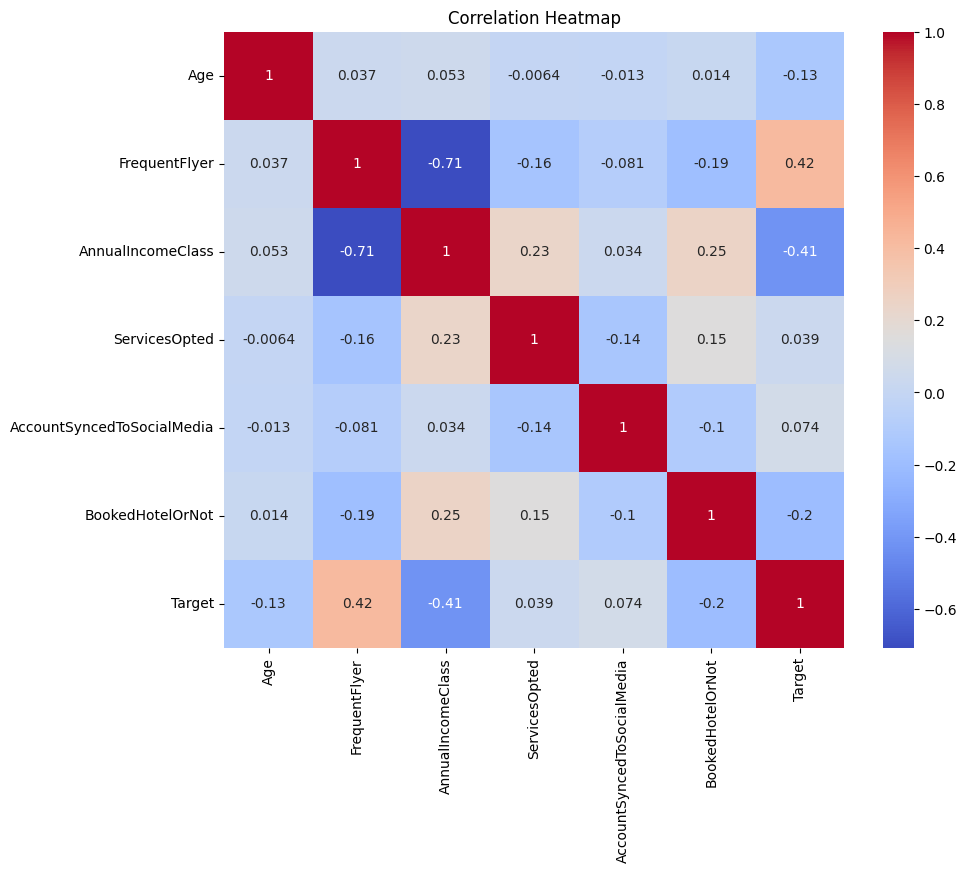

In [ ]:
# Question 15: Plot heatmap of correlations

plt.figure(figsize=(10, 8))
sns.heatmap(data_travel.corr(), cmap='coolwarm', annot=True)
plt.title('Correlation Heatmap')
plt.show()

Now, let's separate the dataset into features (X) and labels (y). Then, split the data into train and test sets using `train_test_split` function from Sklearn with `test_size=0.2`, `random_state=42`, and set `stratify=y` to preserve the label distribution in both sets.

In [ ]:
# Seperate the dataset into features and labels
# X são todas as colunas, exceto a de destino
df_travel2 = pd.DataFrame(data_travel)
X_travel = df_travel2.drop(columns=['Target'])
# y é apenas a coluna de destino
y_travel = df_travel2['Target']
# TODO: Your code here

In [ ]:
# Split into train and test sets
# TODO: Your code here

# Split data into train and test sets, create linear regression model and fit into the training data
X_train_travel, X_test_travel, y_train_travel, y_test_travel = train_test_split(X_travel, y_travel, test_size=0.2, random_state=42, stratify=y_travel)

Before building any model, it's useful to establish a simple reference point. Imagine predicting the most frequent class for every single observation—no learning, just repetition. The accuracy you'd get from that naive approach is called the baseline accuracy. It’s the minimum benchmark any meaningful model should aim to outperform.

In [ ]:
# Question 16: Calculate baseline accuracy
# Calcular a baseline accuracy
baseline_accuracy = y_travel.value_counts(normalize=True).max()
print(f"Baseline Accuracy: {baseline_accuracy:.2%}")
#se você escolher o número mais frequente
# TODO: Your code here

Baseline Accuracy: 76.56%


Now, let's standardize the features using `StandardScaler` from Sklearn.

In [ ]:
# StandardScaler: centraliza os dados (média 0 e desvio padrão 1).
# É útil quando os dados têm unidades diferentes ou estão aproximadamente em distribuição normal.

#Criar o objeto scaler
scaler = StandardScaler()

#Ajustar o scaler aos dados de treino (importante: nunca use o teste aqui!)
scaler.fit(X_train_travel)
#Transformar os dados de treino e teste com o mesmo scaler
X_train_scaled = scaler.transform(X_train_travel)
X_test_scaled = scaler.transform(X_test_travel)

## Exercise 2: Logistic regression

First, try use logistic regression for use our data. Use LogisticRegression with the following setting:
`penalty='l2', solver='lbfgs', max_iter=1000, random_state=30`

In [ ]:
# Logistic Regression
#Create model
model_linear_regression_travel = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=30)
#Fit model
model_linear_regression_travel.fit(X_train_travel, y_train_travel)


# TODO: Your code here
#Mas atenção: nunca aplique .fit() no X_test, pois isso "vaza" informação do teste para o treino.

LogisticRegression(max_iter=1000, random_state=30)

In [ ]:
# Question 17: Find the test accuracy

y_pred_travel_1 = model_linear_regression_travel.predict(X_test_travel)
print(y_pred_travel)

# but with what probability does our model predict each label?
model_linear_regression_travel.predict_proba(X_test_travel)[0:5]
# TODO: Your code here

#Use model on test and check accuracy
print('Accuracy of Logistic regression classifier on test set: {:.4f}'
     .format(model_linear_regression_travel.score(X_test_travel, y_test_travel)))

# Also possible to calculate accuracy on the training set
#print('Accuracy of Logistic regression classifier on training set: {:.2f}'
#     .format(model.score(X_train_travel, y_train_travel)))
#print(f"ACCURACY SCORE (TEST SET): {accuracy_score(y_test, y_pred) :.2f}")

[0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 0 1 1 0 1 0
 0 0 0 1 0 0 0]
Accuracy of Logistic regression classifier on test set: 0.8542


Next, train a logistic regression classifier with cross-validation. Use 5 folds and 9 values in the logscale between $10^{-4}$ and $10^4$ for the regularizer parameter. For the rest of the arguments, we use the same values as we used for the logistic regression with no cross validation.

__Important:__ Set the following values for the arguments:
`
penalty='l2', solver='lbfgs', max_iter=1000, random_state=42, cv=4, Cs=*9*
`

In [ ]:
# Train a logistic regression classifier with cross-validation
# TODO: Your code here
model_cv = LogisticRegressionCV(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42, cv=4, Cs=9)
model_cv.fit(X_train_travel, y_train_travel)

LogisticRegressionCV(Cs=9, cv=4, max_iter=1000, random_state=42)

In [ ]:
# Question 18: Find the value of the regularization parameter and the test accuracy

print(f"Best regularization parameter (C): {model_cv.C_}")
print(f"Test accuracy: {model_cv.score(X_test_travel, y_test_travel)}")

Best regularization parameter (C): [1.]
Test accuracy: 0.8541666666666666


## Exercise 3: KNN classifier

Use the KNeighborClassifier from sklearn using the following setting:
`n_neighbors=7, p=2, weights='uniform', algorithm="kd_tree"`

In [ ]:
# KNeighborClassifier
KNN_classifier_travel = KNeighborsClassifier(n_neighbors=7, p=2, weights='uniform', algorithm='kd_tree')
# TODO: Your code here

Use `GridSearchCV` to find the best hyper-parameters for your KNN model. Use values between 1 and 10 for `n_neighbors` argument and use either 'uniform' or 'distance' for the `weights` argument. Use a 5-fold cross validation. This translate to the following values for the arguments of the `GridSearchCV`:
```
param_grid={"n_neighbors": range(1, 11), "weights":["uniform", "distance"]}, cv=5
```

In [ ]:

# Inicialização das melhores acurácias
best_acc_uniform = 0
best_k_uniform = 0

best_acc_distance = 0
best_k_distance = 0

print("Resultados com weights='uniform':")
for k in range(1, 11):
    model_uniform = KNeighborsClassifier(n_neighbors=k, weights="uniform")
    model_uniform.fit(X_train_travel, y_train_travel)
    acc_uniform = model_uniform.score(X_test_travel, y_test_travel)

    if acc_uniform > best_acc_uniform:
        best_acc_uniform = acc_uniform
        best_k_uniform = k

    print(f"Accuracy k = {k}: {acc_uniform:.4f}")

print("\nResultados com weights='distance':")
for k in range(1, 11):
    model_distance = KNeighborsClassifier(n_neighbors=k, weights="distance")
    model_distance.fit(X_train_travel, y_train_travel)
    acc_distance = model_distance.score(X_test_travel, y_test_travel)

    if acc_distance > best_acc_distance:
        best_acc_distance = acc_distance
        best_k_distance = k

    print(f"Accuracy k = {k}: {acc_distance:.4f}")

print("\nMelhores resultados:")
print(f"Best uniform -> k = {best_k_uniform}, accuracy = {best_acc_uniform:.4f}")
print(f"Best distance -> k = {best_k_distance}, accuracy = {best_acc_distance:.4f}")

Resultados com weights='uniform':
Accuracy k = 1: 0.8750
Accuracy k = 2: 0.8594
Accuracy k = 3: 0.8750
Accuracy k = 4: 0.8594
Accuracy k = 5: 0.8802
Accuracy k = 6: 0.8490
Accuracy k = 7: 0.8698
Accuracy k = 8: 0.8594
Accuracy k = 9: 0.8594
Accuracy k = 10: 0.8542

Resultados com weights='distance':
Accuracy k = 1: 0.8750
Accuracy k = 2: 0.8594
Accuracy k = 3: 0.8750
Accuracy k = 4: 0.8750
Accuracy k = 5: 0.8802
Accuracy k = 6: 0.8698
Accuracy k = 7: 0.8594
Accuracy k = 8: 0.8646
Accuracy k = 9: 0.8594
Accuracy k = 10: 0.8594

Melhores resultados:
Best uniform -> k = 5, accuracy = 0.8802
Best distance -> k = 5, accuracy = 0.8802


In [ ]:

# Question 19: Find the accuracy of the best KNN model

# Parâmetros a testar
param_grid = {
    "n_neighbors": range(1, 11),
    "weights": ["uniform", "distance"]
}

# GridSearchCV com validação cruzada (cv = 5)
grid = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=param_grid, cv=5)

# Treinamento com os dados de treino
grid.fit(X_train_travel, y_train_travel)

# Encontrando os melhores hiperparâmetros
best_n_neighbors = grid.best_params_["n_neighbors"]
best_weights = grid.best_params_["weights"]

print(best_n_neighbors, best_weights)
# Treinando o modelo com os melhores parâmetros
knn_best = KNeighborsClassifier(n_neighbors=best_n_neighbors, weights=best_weights)
knn_best.fit(X_train_travel, y_train_travel)

# Avaliando a acurácia com os dados de teste
test_accuracy = knn_best.score(X_test_travel, y_test_travel)
print("Test accuracy of the best KNN model:", round(test_accuracy, 4))

8 distance
Test accuracy of the best KNN model: 0.8646


In [ ]:
# Question 20: Find the 'n_neighbors' and 'weights' values for the best KNN model

param_grid = {
    'n_neighbors': np.arange(1, 10),   # Testa k de 1 a 9
    'p': [1, 2],                       # 1 = Manhattan, 2 = Euclidiana
    'weights': ['uniform', 'distance']  # Tipos de pesos
}


data_knn = KNeighborsClassifier()

# Aplicar GridSearchCV com validação cruzada
data_knn_cv = GridSearchCV(data_knn, param_grid, cv=5)
data_knn_cv.fit(X_train_travel, y_train_travel)

# Resultados
print("Top Hyperparameters:", data_knn_cv.best_params_)              # Mostra os melhores valores encontrados
print("Top Cross-Validated Train Score:", round(data_knn_cv.best_score_, 4))
print("Test Score/ Best Model:", round(data_knn_cv.score(X_test_travel, y_test_travel), 4))

Top Hyperparameters: {'n_neighbors': np.int64(8), 'p': 2, 'weights': 'distance'}
Top Cross-Validated Train Score: 0.8945
Test Score/ Best Model: 0.8646


## Exercise 4: Decision Tree

Train a Decision Tree classifier on the training data. Use the following values for the arguments of the decision tree:
```
criterion="gini", max_depth=3, random_state=30
```

Use `GridSearchCV` to find the best hyper-parameters for your decision tree model. Use values between 1 and 7 for `max_depth` argument and use either 'gini' or 'entropy' for the `criterion` argument. Use a 5-fold cross validation. This translate to the following values for the arguments of the `GridSearchCV`:
```
param_grid={"max_depth": range(1, 8), "criterion":["gini", "entropy"]}, cv=5
```

In [ ]:

# # QUESTION 21:
# Decision Tree

# fixed decision tree one
model_travel = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=30)
model_travel.fit(X_train_travel, y_train_travel)
print( round(model_travel.score(X_test_travel, y_test_travel), 4))

#GridSearch parameters
param_grid = {
    "max_depth": range(1, 8),
    "criterion": ["gini", "entropy"]
}

# random_state=30
travel_tree = DecisionTreeClassifier(random_state=30)
travel_cvtree = GridSearchCV(estimator=travel_tree, param_grid=param_grid)
travel_cvtree.fit(X_train_travel, y_train_travel)

# resultado
print("TestScore Best Model:", round(travel_cvtree.score(X_test_travel, y_test_travel), 4))

0.8542
TestScore Best Model: 0.8958


In [ ]:

# QUESTION 22:
# Find the 'criterion' and 'max_depth' values for the best decision tree model
# TODO: Your code here
print("Best criterion:", travel_cvtree.best_params_['criterion'])
print("Best max_depth:", travel_cvtree.best_params_['max_depth'])

Best criterion: gini
Best max_depth: 6


The company places a strong emphasis on keeping its customers and has solid resources dedicated to retention. In such a case, choosing the right evaluation metric becomes crucial. The answer lies in understanding what matters most in this context.


Question 23: Find the best metric for the company

> TODO: Recal


Recall minimizes false-negatives cases where the model predicts that a customer will stay, but they actually leave. These are the most harmful errors for the company.

In contrast, false positives(predicting that a customer will leave when they won’t) are less critical and this is the other one correlated(Precision). because the company can handle extra retention efforts.

In [ ]:
# Question 24: Determine which model performs best according to recall

model_recalls = {
    'Logistic Regression': recall_score(y_test_travel, y_pred_travel_1),
    'KNN': recall_score(y_test_travel, y_pred_travel_2),
    'Decision Tree': recall_score(y_test_travel, y_pred_travel_3)
}

best_model_name = max(model_recalls, key=model_recalls.get)
best_model_recall = model_recalls[best_model_name]

print(f"The model with the highest Recall is: {best_model_name} with a Recall of {best_model_recall}")

The model with the highest Recall is: Logistic Regression with a Recall of 0.5333333333333333
